# Cuba administrative map

Plot the published administrative geometry with labels and point locations from the geographic names dataset. This follows the work repository's `plot_cuba_province_outlines.py`.

Use a Python environment with `geopandas`, `pyarrow`, and `matplotlib`. Run the cells from top to bottom from the repository root or `examples/` directory.


In [7]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "examples":
    ROOT = ROOT.parent

ADMIN_GEOMETRY = ROOT / "data/administrative-geometry/cuba_administrative_geometry.parquet"
ADMIN_NAMES = ROOT / "data/administrative-geographic-names/cuba_administrative_geographic_names.parquet"

units = gpd.read_parquet(ADMIN_GEOMETRY)
names = gpd.read_parquet(ADMIN_NAMES).to_crs(units.crs)
print(f"Administrative units: {len(units):,}")
print(f"Geographic names: {len(names):,}")
print(f"CRS: {units.crs.to_string()}")

Administrative units: 183
Geographic names: 183
CRS: EPSG:4326


## Administrative levels and name locations

Link geometry `gazetteer_id` to the geographic names `id`. Label text and positions come from the matched names, not polygon centroids.

Isla de la Juventud (`special_municipality`) participates at both province and municipality levels. Its single geometry record is included in both selections.


In [8]:
labels = names[["id", "name", "geometry"]].merge(
    units[["gazetteer_id", "level"]],
    left_on="id", right_on="gazetteer_id",
)

province_levels = ["province", "special_municipality"]
municipality_levels = ["municipality", "special_municipality"]
provinces = units.loc[units["level"].isin(province_levels)]
municipalities = units.loc[units["level"].isin(municipality_levels)]
province_labels = labels.loc[labels["level"].isin(province_levels)]

## Map

Province fills, thin municipal boundaries, and province labels use the same styling as the plotting script.

The published repository does not include the script's separate land/coastline dataset. Here the outline is derived by combining the province-level geometries, so it shows the islands and keys represented in this product. It is not an independent coastline dataset.


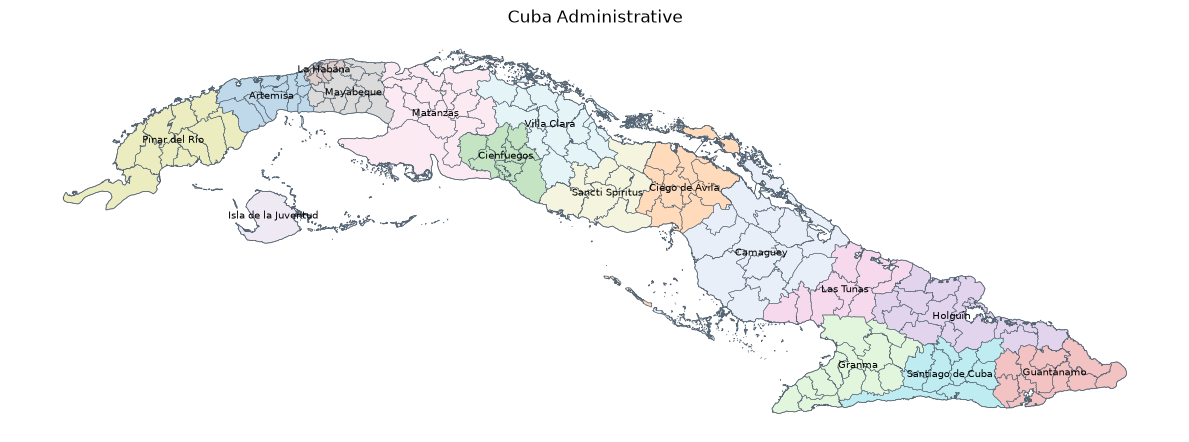

In [9]:
land_outline = gpd.GeoSeries([provinces.geometry.union_all()], crs=units.crs)

fig, ax = plt.subplots(figsize=(12, 9))
provinces.plot(
    ax=ax, column="name", categorical=True, cmap="tab20", alpha=0.28,
    edgecolor="none", legend=False, zorder=1,
)
municipalities.boundary.plot(ax=ax, color="#566573", linewidth=0.35, zorder=2)
land_outline.boundary.plot(ax=ax, color="#566573", linewidth=0.5, zorder=4)

for row in province_labels.itertuples(index=False):
    ax.text(
        row.geometry.x, row.geometry.y, row.name,
        ha="center", va="center", fontsize=7, zorder=5,
    )

ax.set_title("Cuba Administrative")
ax.set_axis_off()
fig.tight_layout()
plt.show()

# to save the map, uncomment the following line
# fig.savefig(ROOT / "examples/administrative_map.png", dpi=220, bbox_inches="tight")